# Laboratorio 04 - Ejercicion de programación de Regresión Logistica

**Nombre del alumno**: Nisse Maximiliano Martinez Pardo \
**Link a github del laboratorio**: https://github.com/nmmartinezp/SIS420-Inteligencia-Artifical---NMMP/tree/master/Laboratorios/laboratorio%2004 \
**Link de dataset**: https://www.kaggle.com/datasets/mobeenfatimah/cardiovascular-disease-risk-prediction-dataset#1

## Contexto del dataset

El conjunto de datos simula datos demográficos, hábitos de vida, mediciones clínicas, resultados de laboratorio y factores de riesgo cardiovascular realistas de los pacientes. Es adecuado para fines educativos, de investigación y de modelado predictivo.

## Librerias usadas

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

## Cargar datos del csv - Cardiovascular Disease Risk Prediction Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Courses/SIS420 Inteligencia artidicial I/Datasets/cardiovascular_disease_prediction.csv')

# Ver las primeras filas
print("Primeras 5 filas:")
print(df.head())

Primeras 5 filas:
   Patient_ID  Age  Gender  Height_cm  Weight_kg   BMI  \
0      110651   41  Female      165.6       89.0  32.5   
1      102042   43  Female      163.1       40.0  15.0   
2      108669   37  Female      154.0       96.2  40.6   
3      101115   81  Female      168.7       72.8  25.6   
4      113903   32  Female      176.7       53.1  17.0   

   Blood_Pressure_Systolic  Blood_Pressure_Diastolic  Heart_Rate  Cholesterol  \
0                      118                        79          85          248   
1                      114                        55          73          219   
2                      127                        74          68          219   
3                      137                        87          70          154   
4                      144                        79          66          225   

   ...  Shortness_of_Breath  ECG_Result  Medication  Diet_Quality  \
0  ...                   No      Normal          No       Average   
1  ...  

## Preprocesamiento de Datos

In [4]:
# Manejar valores nulos
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Codificar TODAS las variables categóricas
from sklearn.preprocessing import LabelEncoder

# Columnas categóricas
categorical_cols = ['Gender', 'Physical_Activity', 'Stress_Level', 'Family_History',
                    'Chest_Pain', 'Shortness_of_Breath', 'ECG_Result',
                    'Medication', 'Diet_Quality', 'Region', 'Education_Level',
                    'BMI_Category']

# Aplicar LabelEncoder a TODAS las columnas categóricas
le_dict = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

# Verificar si quedaron columnas de texto
remaining_object_cols = df.select_dtypes(include=['object']).columns
if len(remaining_object_cols) > 0:
    for col in remaining_object_cols:
        if col != 'Cardiovascular_Disease':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            le_dict[col] = le

# Verificar que todas las columnas sean numéricas ahora
print("\nTipos de datos después de codificación:")
print(df.dtypes)

# Identificar la variable objetivo
target_col = 'Cardiovascular_Disease'

# Separar características y objetivo
X = df.drop([target_col, 'Annual_Income_USD', 'Patient_ID'], axis=1)
y = df[target_col].values

# Asegurar que todos los datos sean numéricos (float)
X = X.astype(float).values
y = y.astype(float)

m, n = X.shape


Tipos de datos después de codificación:
Patient_ID                    int64
Age                           int64
Gender                        int64
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Heart_Rate                    int64
Cholesterol                   int64
HDL                         float64
LDL                         float64
Triglycerides               float64
Blood_Glucose               float64
Diabetes                      int64
Hypertension                  int64
Smoking                       int64
Alcohol_Consumption           int64
Physical_Activity             int64
Exercise_Days_Per_Week        int64
Daily_Walking_Minutes         int64
Sleep_Hours                 float64
Stress_Level                  int64
Family_History                int64
Chest_Pain                    int64
Shortness_of_Breath           int64
ECG_Result             

## Normalizar

In [5]:
def  featureNormalize(X):

    X_norm = X.copy()

    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [6]:
X_norm, mu, sigma = featureNormalize(X)

X_final = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"\nDatos preparados: {X_final.shape[0]} muestras, {X_final.shape[1]} características")
print(f"Tipo de datos: {X_final.dtype}")
print(f"Rango de valores: min={X_final.min():.2f}, max={X_final.max():.2f}")


Datos preparados: 20000 muestras, 33 características
Tipo de datos: float64
Rango de valores: min=-3.14, max=5.07


## Funciones para Regresion Logistica

In [7]:
# Fución Sigmoidea
def sigmoid(z):
    z = np.array(z)
    return 1 / (1 + np.exp(-z))

# Función de Costo y Gradiente
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

# funcion de Costo para uso en
def costFunction(theta, X, y):
    m = y.size
    J = 0
    grad = np.zeros(theta.shape)
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad


def predict(theta, X):
    m = X.shape[0]
    p = np.zeros(m)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p


## Aplicando Descenso por el gradiente

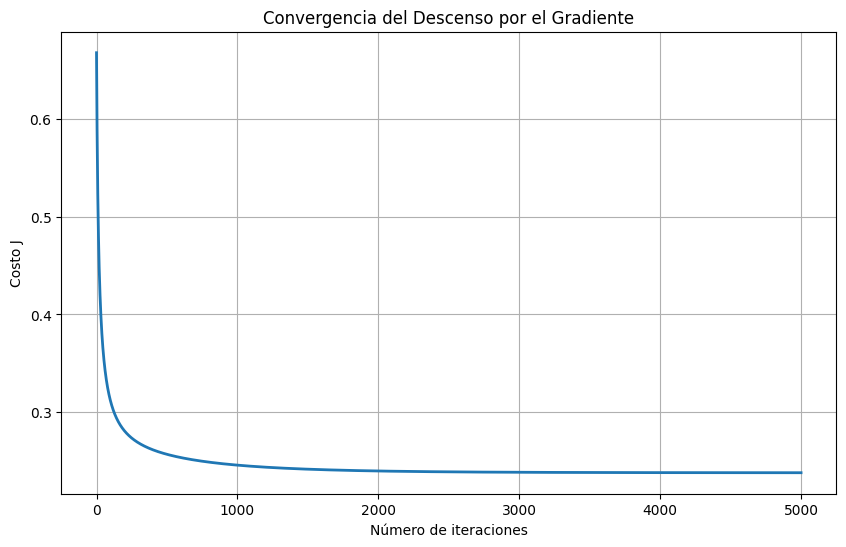

theta calculado por el descenso por el gradiente: [-2.14929227e+00 -2.83556208e-02  6.95340317e-03  6.08895681e-02
 -2.66984233e-02  1.87467222e-02  4.72996590e-02 -3.55190257e-02
  1.01455901e-02 -4.18787713e-03  4.59464480e-02 -6.49514479e-03
  2.63607402e-03 -2.29906684e-02 -1.80118378e-02 -1.41741626e-02
 -9.71469125e-03  9.65702166e-03 -3.14090969e-02  7.39836176e-03
  2.81826553e-02 -4.72522389e-03  9.50899833e-03 -3.66255451e-02
  4.94606215e-02 -3.97193385e-03  2.52975975e-03 -1.51377480e-02
 -7.61700399e-03 -3.99772286e-03 -1.94350316e-02  2.01735146e-02
  4.12060061e+00]
Probabilidad de enfermedad cardiovascular: 89.92%
Precisión de entrenamiento: 96.25 %


In [8]:
# Inicializar theta
initial_theta = np.zeros(X_final.shape[1])

# Parámetros del descenso por el gradiente
alpha = 0.1
num_iters = 5000

# Ejecutar descenso por el gradiente
theta_gd, J_history = descensoGradiente(initial_theta, X_final, y, alpha, num_iters)

# Graficar convergencia
pyplot.figure(figsize=(10, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta_gd)))

# Ejemplo: crear un nuevo paciente con características específicas
nuevo_paciente = np.array([[
    41,     # Age
    0,      # Gender (Female=0, Male=1)
    165.6,  # Height_cm
    89.0,   # Weight_kg
    32.5,   # BMI
    118,    # Blood_Pressure_Systolic
    79,     # Blood_Pressure_Diastolic
    85,     # Heart_Rate
    248,    # Cholesterol
    120,    # HDL (colesterol bueno)
    150,    # LDL (colesterol malo)
    180,    # Triglycerides
    110,    # Blood_Glucose
    0,      # Diabetes (0=No, 1=Yes)
    0,      # Hypertension (0=No, 1=Yes)
    0,      # Smoking (0=No, 1=Yes)
    0,      # Alcohol_Consumption (0=No, 1=Yes)
    1,      # Physical_Activity (0=Low, 1=Moderate, 2=High)
    5,      # Exercise_Days_Per_Week
    60,     # Daily_Walking_Minutes
    7,      # Sleep_Hours
    1,      # Stress_Level (0=Low, 1=Moderate, 2=High)
    0,      # Family_History (0=No, 1=Yes)
    0,      # Chest_Pain (0=No, 1=Yes)
    0,      # Shortness_of_Breath (0=No, 1=Yes)
    0,      # ECG_Result (0=Normal, 1=Abnormal)
    0,      # Medication (0=No, 1=Yes)
    1,      # Diet_Quality (0=Poor, 1=Average, 2=Healthy)
    0,      # Region (0=Central, 1=East, 2=North, 3=South, 4=West)
    1,      # Education_Level (0=High School, 1=Bachelor, 2=Master, 3=PhD)
    2,      # BMI_Category (0=Underweight, 1=Normal, 2=Overweight, 3=Obese)
    14,     # Risk_Score
]])

# Normzalizar paciente nuevo
nuevo_paciente_norm = (nuevo_paciente - mu) / sigma

# Agregar columna de unos
nuevo_paciente_final = np.concatenate([np.ones((1, 1)), nuevo_paciente_norm], axis=1)

# Predecir
probabilidad = sigmoid(np.dot(nuevo_paciente_final, theta_gd))



print(f"Probabilidad de enfermedad cardiovascular: {probabilidad[0]*100:.2f}%")
# Compute accuracy on our training set
p = predict(theta_gd, X_final)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))

## Parámetros de aprendizaje usando scipy.optimize

In [9]:
options= {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_final, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost_om = res.fun
theta_om = res.x

print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost_om))

print('theta:')
print('\t[{:.3f}, {:.3f}, {:.3f}]'.format(*theta_om))

Costo con un valor de theta encontrado por optimize.minimize: 0.238
theta:
	[-2.178, -0.040, 0.007]


In [10]:
prob = sigmoid(np.dot(nuevo_paciente_final, theta_om))
print(f"Probabilidad de enfermedad cardiovascular: {prob[0]*100:.2f}%")

# Compute accuracy on our training set
p = predict(theta_om, X_final)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))

Probabilidad de enfermedad cardiovascular: 91.03%
Precisión de entrenamiento: 96.25 %
